# Vectora Sports-Ball Classification

**Scenario** (project brief): Vectora is an online sports-equipment shop. Hundreds of
product photos (sports balls) are uploaded daily and currently classified by hand.
This prototype answers: *can Computer Vision automatically recognise the type of ball
from a photo?* — 15 ball classes.

This is the **main project notebook**. It contains everything the brief requires:

1. **Task 1** — preprocessing, training, performance evaluation and error analysis on
   the original dataset (train/test splits shipped with the project).
2. **Task 2** — a brand-new test set of images collected from the internet
   (`new_test_set/`), evaluated with the already-trained model (no retraining).

**Prepared by:MS.SanamAsghari MR.HamidRezaNasrollahi**

Environment: CPU/T4 GPU(Google Colab), PyTorch, 15-class classification, images resized to 224x224.


The project follows this **pipeline**:

Image/Video → Preprocessing → Model → Training → Evaluation → Prediction → Deployment

# Task 1 — Shared backbone: ResNet18 (ImageNet, frozen)


In [1]:
import os

from pathlib import Path
from PIL import Image
from collections import Counter
import hashlib
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
x = torch.tensor([1.0, 2.0, 3.0]).to(device)

print(x)

tensor([1., 2., 3.], device='cuda:0')


Define the dataset paths and the main training parameters such as
image size, batch size, number of epochs, validation ratio, and seed.

In [6]:
DATA_DIR = Path("/content/drive/MyDrive/Project_Dataset/train")  # Folder where data will be stored
TEST_DIR = Path("/content/drive/MyDrive/Project_Dataset/test")

IMG_SIZE = 224      # Good default for ResNet
BATCH_SIZE = 32
EPOCHS = 10
VAL_RATIO = 0.2     # Split trainval into train/val
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Load dataset from Google Driver to Google Colab

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
for root, dirs, files in os.walk(DATA_DIR):
    print(root, len(files))
    if root != DATA_DIR: break

/content/drive/MyDrive/Project_Dataset/train 0


In [ ]:
!find /content/drive/MyDrive/Project_Dataset -maxdepth 2 -type d

/content/drive/MyDrive/Project_Dataset
/content/drive/MyDrive/Project_Dataset/test
/content/drive/MyDrive/Project_Dataset/test/football
/content/drive/MyDrive/Project_Dataset/test/hockey_puck
/content/drive/MyDrive/Project_Dataset/test/hockey_ball
/content/drive/MyDrive/Project_Dataset/test/table_tennis_ball
/content/drive/MyDrive/Project_Dataset/test/volleyball
/content/drive/MyDrive/Project_Dataset/test/rugby_ball
/content/drive/MyDrive/Project_Dataset/test/american_football
/content/drive/MyDrive/Project_Dataset/test/billiard_ball
/content/drive/MyDrive/Project_Dataset/test/golf_ball
/content/drive/MyDrive/Project_Dataset/test/shuttlecock
/content/drive/MyDrive/Project_Dataset/test/bowling_ball
/content/drive/MyDrive/Project_Dataset/test/baseball
/content/drive/MyDrive/Project_Dataset/test/basketball
/content/drive/MyDrive/Project_Dataset/test/tennis_ball
/content/drive/MyDrive/Project_Dataset/test/cricket_ball
/content/drive/MyDrive/Project_Dataset/train
/content/drive/MyDrive/Proj

## EDA & Data Cleaning

### Count images per class

In [7]:
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {num_images}")

table_tennis_ball: 613
rugby_ball: 488
football: 604
american_football: 380
golf_ball: 536
basketball: 340
cricket_ball: 581
hockey_ball: 507
hockey_puck: 385
volleyball: 428
shuttlecock: 425
billiard_ball: 639
baseball: 395
bowling_ball: 435
tennis_ball: 484


### Check image dimensions

In [8]:
for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        dimensions = []

        for img_path in folder.iterdir():
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)
                except:
                    pass

        print(f"\n{folder.name}")
        print(Counter(dimensions).most_common(10))


table_tennis_ball
[((225, 225), 120), ((800, 800), 20), ((275, 183), 16), ((600, 400), 12), ((300, 300), 12), ((500, 500), 11), ((470, 470), 11), ((224, 224), 9), ((400, 400), 9), ((250, 250), 9)]

rugby_ball
[((225, 225), 128), ((259, 194), 16), ((500, 500), 12), ((800, 800), 10), ((1000, 1000), 9), ((600, 600), 8), ((1200, 1200), 7), ((275, 183), 7), ((1024, 1024), 6), ((700, 700), 6)]

football
[((225, 225), 115), ((300, 300), 59), ((800, 800), 20), ((383, 383), 16), ((265, 265), 16), ((199, 254), 14), ((1280, 720), 14), ((250, 250), 10), ((600, 600), 9), ((275, 183), 8)]

american_football
[((225, 225), 56), ((275, 183), 14), ((512, 512), 8), ((500, 500), 7), ((600, 400), 7), ((1280, 720), 7), ((1000, 1000), 6), ((259, 194), 5), ((1000, 1080), 5), ((300, 168), 5)]

golf_ball
[((225, 225), 86), ((800, 800), 16), ((275, 183), 12), ((1000, 1000), 10), ((600, 600), 8), ((300, 300), 8), ((300, 168), 7), ((1024, 1024), 7), ((259, 194), 6), ((480, 480), 6)]

basketball
[((225, 225), 43),

### Find corrupted images

In [9]:
corrupted = []

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

for img in corrupted:
    print(img)

Corrupted images: 0


### Find duplicate images

In [10]:
hashes = defaultdict(list)

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        hashes[file_hash].append(img_path)

duplicates = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

for h, files in duplicates.items():
    print("\nDuplicate:")
    for file in files:
        print(file)


Duplicate:
/content/drive/MyDrive/Project_Dataset/train/hockey_ball/hockey_ball_629 (1).jpg
/content/drive/MyDrive/Project_Dataset/train/hockey_ball/hockey_ball_629.jpg


duplicated images:

In [ ]:
os.remove("/content/drive/MyDrive/Project_Dataset/train/cricket_ball/cricket_ball_1060 (1).jpg")
os.remove("/content/drive/MyDrive/Project_Dataset/train/cricket_ball/cricket_ball_754 (1).jpg")
os.remove("/content/drive/MyDrive/Project_Dataset/train/cricket_ball/cricket_ball_181 (1).jpg")
os.remove("/content/drive/MyDrive/Project_Dataset/train/cricket_ball/cricket_ball_629 (1).jpg")

In [ ]:
img1_path = "Project_Dataset/train/rugby_ball/rugby_ball_135.jpg"
img2_path = "Project_Dataset/train/american_football/american_football_561.jpg"

img1 = Image.open(img1_path)
img2 = Image.open(img2_path)

display(img1)
display(img2)

In [ ]:
# remove the ambiguous image
os.remove(img1_path)
os.remove(img2_path)

**Reason for removal:**

The image is ambiguous and cannot be reliably classified as either American football or rugby.
Keeping it could introduce label noise and cause the model to learn misleading features such as text or color.

### Visual inspection

we look for things like:

1. Wrongly labeled images
2. Images that belong to another class
3. Corrupted/unreadable images
4. Very unusual images
5. Images where the ball is barely visible
6. Images containing multiple different balls
7. Images with text/watermarks that might give the model the answer
8. background: "Is the background strongly associated with a particular class?"

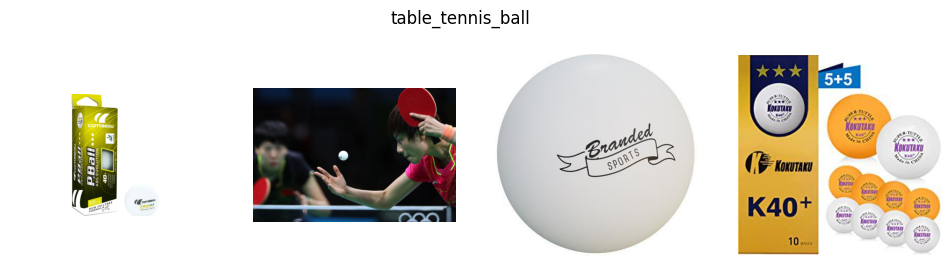

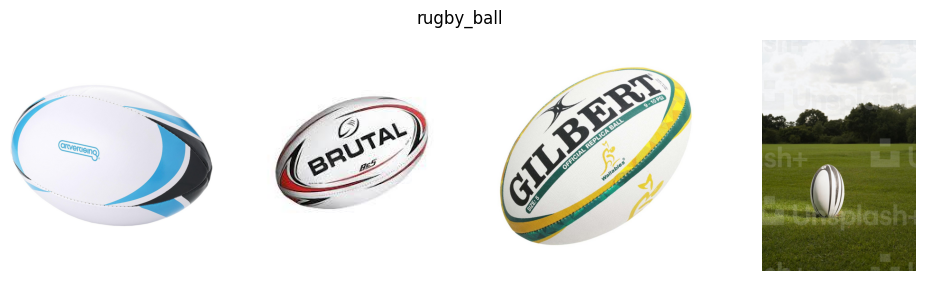

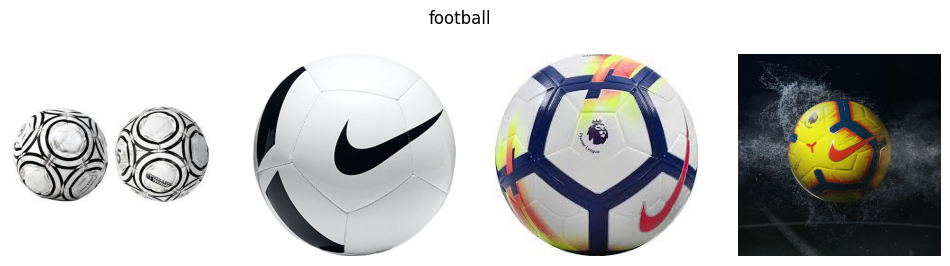

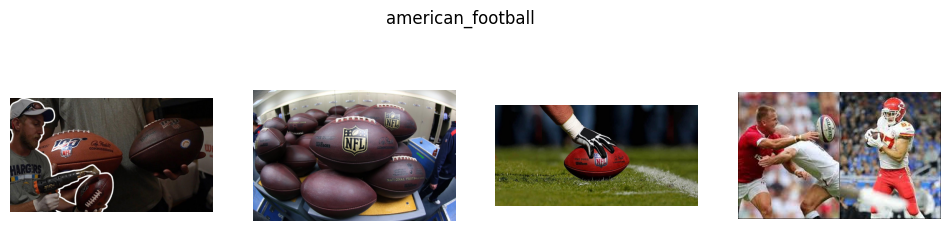

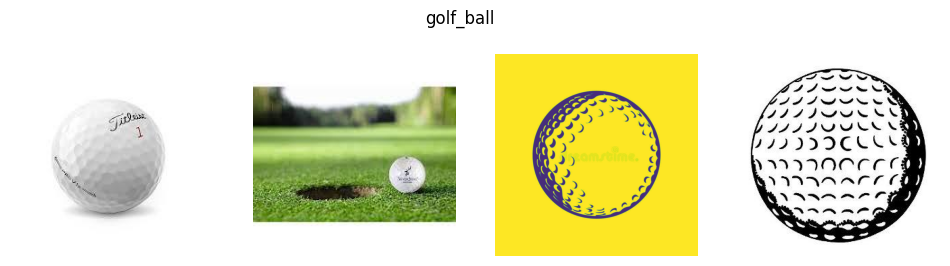

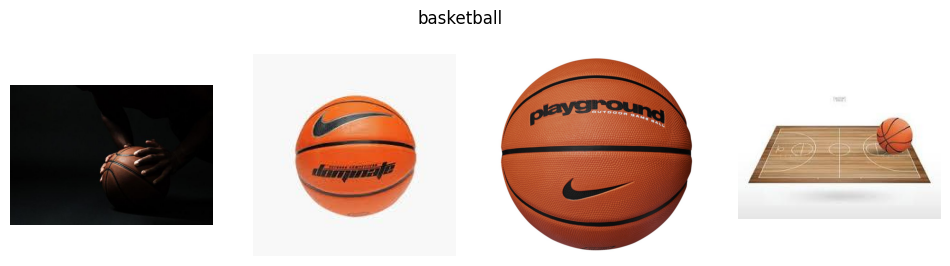

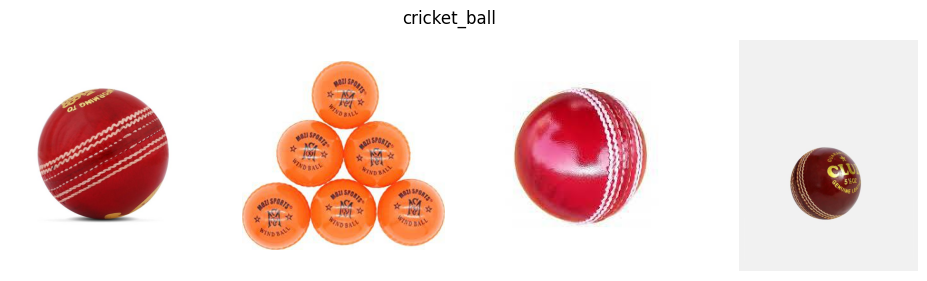

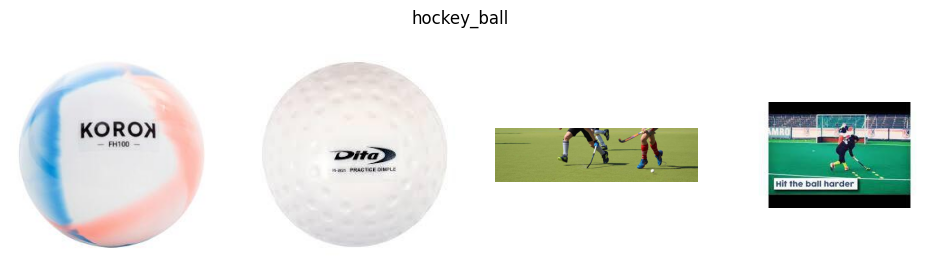

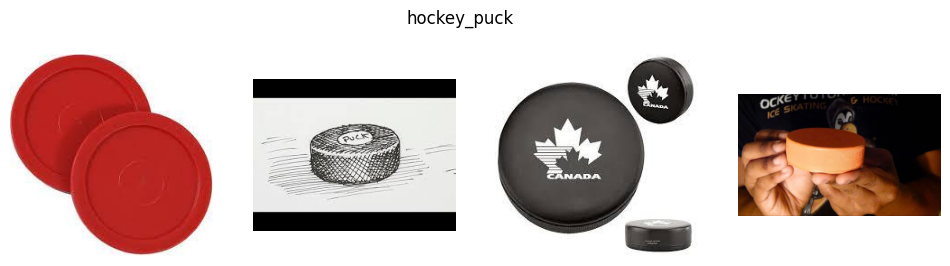

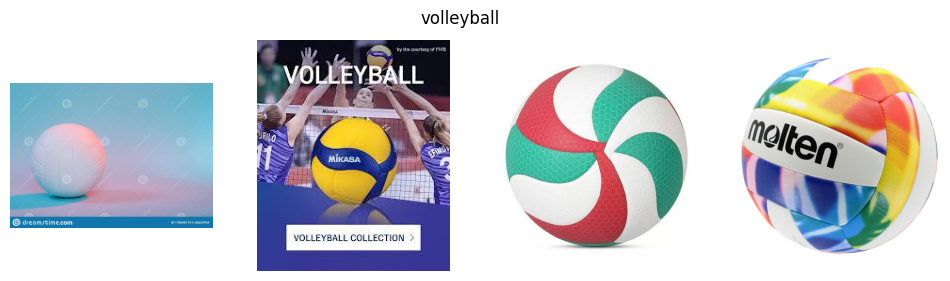

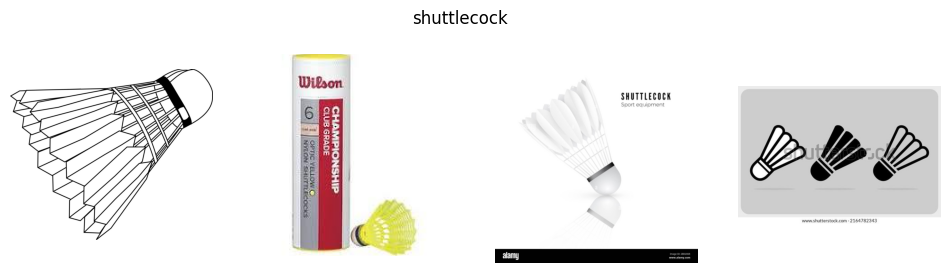

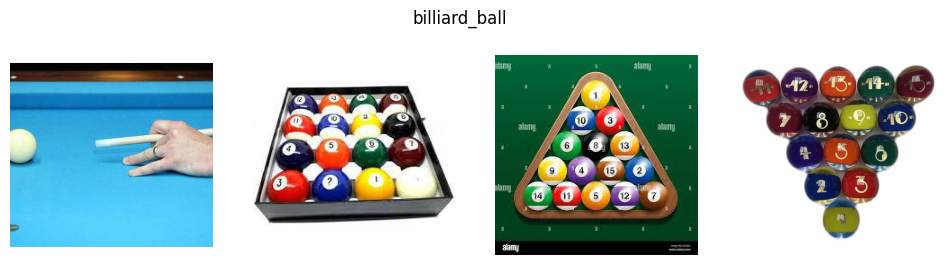

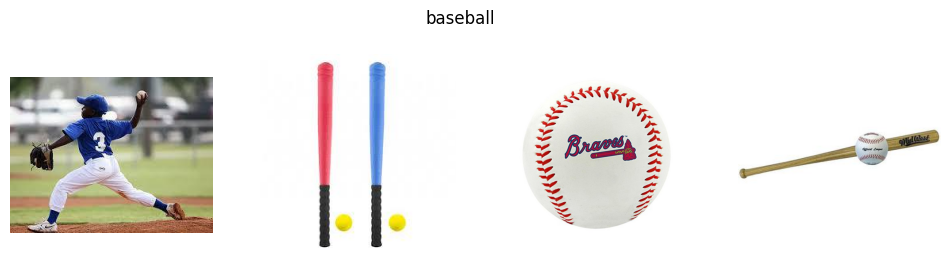

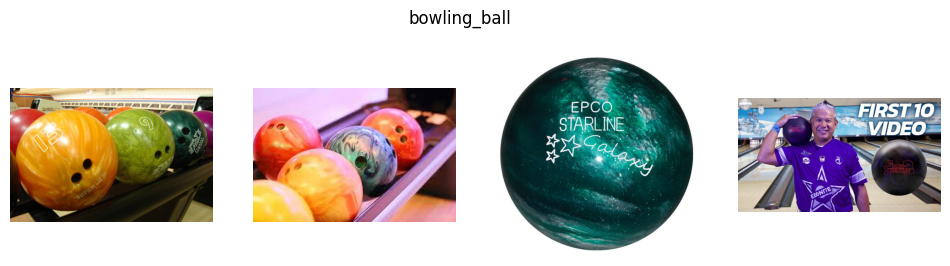

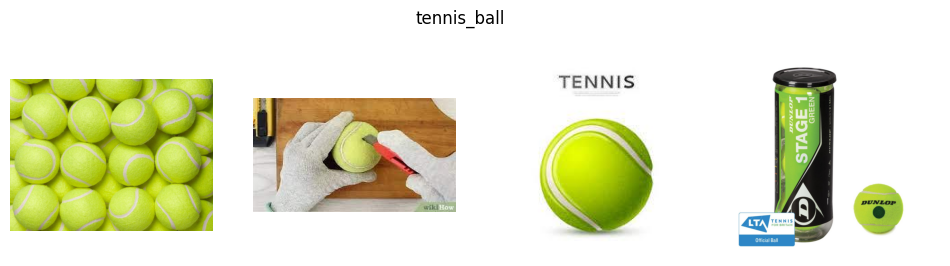

In [12]:
classes = os.listdir(DATA_DIR)

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    selected_images = random.sample(images, min(4, len(images)))

    plt.figure(figsize=(12, 3))
    plt.suptitle(class_name)

    for i, image_name in enumerate(selected_images):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        plt.subplot(1, 4, i + 1)
        plt.imshow(image)
        plt.axis("off")

    plt.show()

In [13]:
selected_images

['tennis_460.jpg', 'tennis_749.jpg', 'tennis_675.jpg', 'tennis_779.jpg']

### Check lighting

In [14]:
import cv2
import numpy as np
from pathlib import Path

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        img = cv2.imread(str(img_path))

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)

        print(img_path, brightness)

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_872.jpg 225.36096790123457
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_1342.jpg 217.91585317460317
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_233.jpg 231.46194662231727
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_293.jpg 207.40035353535353
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_441.jpg 225.15222358703613
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_187.jpg 122.2930344594191
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_227.jpg 199.07307486153297
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_375.jpg 132.25946471371503
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_180.jpg 244.52165925925925
/content/drive/MyDrive/Project_Dataset/train/golf_ball/golf_ball_1322.jpg 105.26129321266968
/content/drive/MyDrive/Proje

unusual images
backgrounds
lighting
different viewpoints
images where the ball is very small
images containing multiple balls

## Preprocessing

### transformers

Use the mean and standard deviation of ImageNet because ResNet18
was pretrained on ImageNet.

Apply data augmentation to training images to create slightly different
versions of images and improve the model's ability to generalize.

In [9]:
# ImageNet normalization (ResNet was trained this way)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training: resize, augment, normalize
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.75, 1.0),
        ratio=(0.8, 1.25)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation/Test: only resize + normalize, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

### Load the train/test dataset

In [10]:
base_dataset = datasets.ImageFolder(
    root=DATA_DIR
)

full_train_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

full_val_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

In [11]:
class_names = base_dataset.classes

num_classes = len(full_train_dataset.classes)  # should be 15
print("Number of classes:", num_classes)

Number of classes: 15


### Train / Validation Split

In [12]:
# ==================================================
#  Train/Validation split (PyTorch / Sci-Kit Learn)
# ==================================================
#PyTorch:
full_size = len(full_train_dataset)
val_size = int(VAL_RATIO * full_size)
train_size = full_size - val_size

train_dataset, val_indices = random_split(
    range(full_size),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = torch.utils.data.Subset(
    full_train_dataset,
    train_dataset
)

val_dataset = torch.utils.data.Subset(
    full_val_dataset,
    val_indices
)

In [13]:
# Sci-Kit Learn

labels = np.array(base_dataset.targets)
indices = np.arange(len(base_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=labels
)

train_dataset = Subset(
    full_train_dataset,
    train_indices
)

val_dataset = Subset(
    full_val_dataset,
    val_indices
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 5792
Validation: 1448


train → augmentation ✅

validation → no augmentation ✅

test → no augmentation ✅

### DataLoaders

DataLoaders divide the datasets into batches and efficiently provide
images to the model during training and evaluation.

In [14]:
# ============================================
#  DataLoaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Balance class weights

There is some imbalance in dataset:

340 → basketball

646 → billiard_ball

Class-weighted CrossEntropy can help the smaller classes.

In [15]:
from collections import Counter

train_labels = labels[train_indices]

class_counts = Counter(train_labels)

class_weights = np.array([
    len(train_labels) / (num_classes * class_counts[i])
    for i in range(num_classes)
])

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")
for name, weight in zip(class_names, class_weights):
    print(f"{name:25s}: {weight.item():.3f}")

Class weights:
american_football        : 1.270
baseball                 : 1.222
basketball               : 1.420
billiard_ball            : 0.756
bowling_ball             : 1.110
cricket_ball             : 0.830
football                 : 0.799
golf_ball                : 0.900
hockey_ball              : 0.951
hockey_puck              : 1.254
rugby_ball               : 0.990
shuttlecock              : 1.136
table_tennis_ball        : 0.788
tennis_ball              : 0.998
volleyball               : 1.126


## Fine-tune Resnet18

Load ResNet18 with pretrained ImageNet weights so the model starts
with useful visual features instead of learning everything from scratch.

In [21]:
# ============================================
#  Load pretrained ResNet18 and modify head
# ============================================

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)
# Freeze all layers (backbone)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace the final fully connected layer:
# Original: model.fc = Linear(512 -> 1000)
# We want: 512 -> num_classes (15)
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, num_classes)
)
model = model.to(device)

# Print model summary-ish info
print(model)
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {num_trainable:,} / {num_total:,}")


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Loss and optimizer

AdamW updates the trainable model parameters using gradients calculated
during backpropagation and applies weight decay for regularization.

Use a smaller learning rate for ResNet's pretrained layer4 and a larger learning rate for the newly initialized classification layer.

**differential learning rates:**

Pretrained layer4 → small LR

New FC layer      → larger LR

because the FC layer starts from random weights while layer4 already contains useful ImageNet features.

In [22]:
# ============================================
#  Loss function & optimizer
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 5e-4
        }
    ],
    weight_decay=1e-4
)

### Adding a Learning-Rate Scheduler

ReduceLROnPlateau lowers the learning rate when validation accuracy stops improving, allowing more careful optimization.

In [18]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

## Training

Process each batch, calculate predictions and loss, then use backpropagation and the optimizer to update the trainable model parameters.

In [23]:
# ============================================
#  Training loop (simple: train loss + val loss)
# ============================================
train_accuracy = []
val_accuracy = []

train_losses = []
val_losses = []

best_val_accuracy = 0.0
best_model_state = None

patience = 6
patience_counter = 0

for epoch in range(EPOCHS):
    # ========
    #  TRAIN
    # ========
    model.train()
    running_train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)           # shape: [batch, num_classes]
        loss = criterion(outputs, labels) # CrossEntropyLoss

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_accuracy = correct / total


    # =============
    #  VALIDATION
    # =============
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_accuracy = val_correct / val_total
    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    # =============
    # save history
    # =============
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracy.append(epoch_train_accuracy)
    val_accuracy.append(epoch_val_accuracy)

    # ==============
    # LEARNING RATE
    # ==============

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    # =============
    # =============
    print(f"Epoch [{epoch+1}/{EPOCHS}] - "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}"
          f"Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Acc: {epoch_val_accuracy:.4f}"
          f"LR: {current_lr:.6f}")

    # =============
    #  BEST MODEL
    # =============

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

        print(
            f"  ✓ New best validation accuracy: "
            f"{best_val_accuracy:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{patience})"
        )

        if patience_counter >= patience:

            print("Early stopping.")

            break


print("\nTraining finished ✅")
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

Epoch [1/10] - Train Loss: 1.2394 | Val Loss: 0.6270Train Acc: 0.6231 | Val Acc: 0.8156LR: 0.000100
  ✓ New best validation accuracy: 0.8156
Epoch [2/10] - Train Loss: 0.5692 | Val Loss: 0.4895Train Acc: 0.8339 | Val Acc: 0.8494LR: 0.000100
  ✓ New best validation accuracy: 0.8494
Epoch [3/10] - Train Loss: 0.3681 | Val Loss: 0.4588Train Acc: 0.8905 | Val Acc: 0.8660LR: 0.000100
  ✓ New best validation accuracy: 0.8660
Epoch [4/10] - Train Loss: 0.2612 | Val Loss: 0.4534Train Acc: 0.9235 | Val Acc: 0.8674LR: 0.000100
  ✓ New best validation accuracy: 0.8674
Epoch [5/10] - Train Loss: 0.2050 | Val Loss: 0.4720Train Acc: 0.9347 | Val Acc: 0.8646LR: 0.000100
  No improvement (1/6)
Epoch [6/10] - Train Loss: 0.1273 | Val Loss: 0.4520Train Acc: 0.9636 | Val Acc: 0.8646LR: 0.000100
  No improvement (2/6)
Epoch [7/10] - Train Loss: 0.0968 | Val Loss: 0.4582Train Acc: 0.9720 | Val Acc: 0.8764LR: 0.000100
  ✓ New best validation accuracy: 0.8764
Epoch [8/10] - Train Loss: 0.0760 | Val Loss: 0.5

The Model performs well, reaching a best validation **accuracy of 87.64%**, which is a strong result. However, train accuracy reaches 98.31% while validation stays around 87–88%, indicating **some overfitting** after about epoch 4–7.
Overall, **epoch 7** is the best checkpoint, and using that saved model is the right choice.

In [24]:
model.load_state_dict(best_model_state)
model = model.to(device)
print(
    f"Loaded best model with "
    f"validation accuracy = "
    f"{best_val_accuracy:.4f}"
)

Loaded best model with validation accuracy = 0.8764


## Evaluation

Evaluate the selected best model on the unseen test dataset to measure its final generalization performance.

In [26]:
# ============================================
#  Test set evaluation (simple)
# ============================================
model.eval()  # evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)           # [batch, num_classes]
        _, preds = torch.max(outputs, 1)  # predicted class index

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.8703


### Confusion Matrix

In [27]:
all_labels = []
all_predictions = []
all_probabilities = []
all_images = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images_device = images.to(device)

        outputs = model(images_device)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predictions = torch.max(probabilities, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

        all_images.extend(images.cpu())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

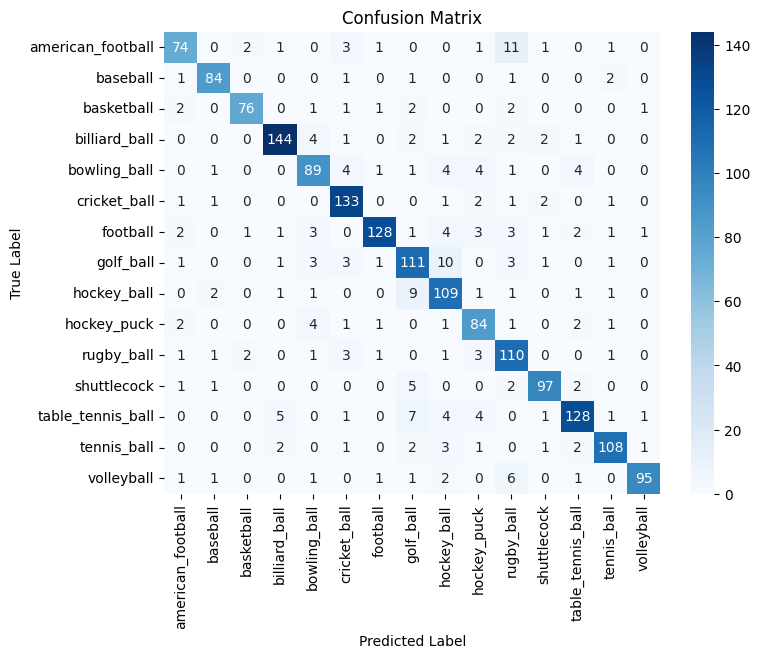

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

**Analyze:**

The model demonstrates strong overall performance, as evidenced by the prominent diagonal values in the confusion matrix, particularly excelling at **classifying distinct items** like billiard balls (144), cricket balls (133), and footballs (128). However, the model **struggles with fine-grained visual distinctions** among similarly shaped objects, revealing specific areas of confusion: it frequently misclassifies golf balls as hockey balls (10 instances), table tennis balls as billiard balls (7 instances), and footballs as rugby balls (4 instances), which intuitively makes sense given their comparable round or oval shapes and sizes. 

### Precision, Recall and F1-score

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

                   precision    recall  f1-score   support

american_football       0.86      0.78      0.82        95
         baseball       0.92      0.93      0.93        90
       basketball       0.94      0.88      0.91        86
    billiard_ball       0.93      0.91      0.92       159
     bowling_ball       0.83      0.82      0.82       109
     cricket_ball       0.88      0.94      0.90       142
         football       0.95      0.85      0.90       151
        golf_ball       0.78      0.82      0.80       135
      hockey_ball       0.78      0.87      0.82       126
      hockey_puck       0.80      0.87      0.83        97
       rugby_ball       0.76      0.89      0.82       124
      shuttlecock       0.92      0.90      0.91       108
table_tennis_ball       0.90      0.84      0.87       152
      tennis_ball       0.92      0.89      0.90       121
       volleyball       0.96      0.87      0.91       109

         accuracy                           0.87      

**Analyze:**

The model achieves a solid 87% overall accuracy with balanced macro and weighted averages, showing consistent performance across all 15 classes.
It excels at distinct shapes like baseballs (0.93 F1), billiard balls (0.92), and shuttlecocks (0.91).
The weakest class is golf balls (0.80 F1), likely due to visual confusion with other small spherical objects.
Rugby balls have the lowest precision (0.76) indicating many false positives, while footballs show high precision (0.95) but lower recall (0.85)

### Find misclassified images

In [30]:
misclassified = []

for i in range(len(all_labels)):

    if all_labels[i] != all_predictions[i]:

        confidence = np.max(all_probabilities[i])

        misclassified.append({
            "index": i,
            "true": all_labels[i],
            "predicted": all_predictions[i],
            "confidence": confidence
        })

print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 234


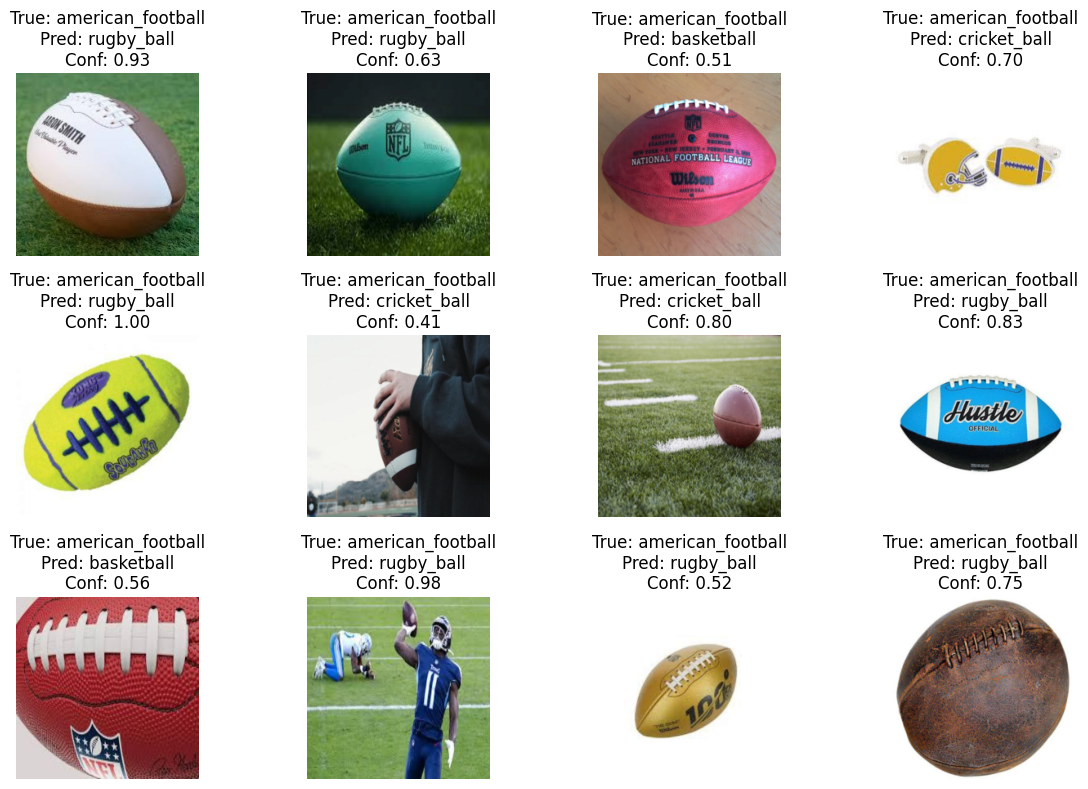

In [ ]:
num_images = min(12, len(misclassified))

plt.figure(figsize=(12, 8))

mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)

for i in range(num_images):

    item = misclassified[i]

    index = item["index"]

    image = all_images[index]

    # Unnormalize
    image = image * std + mean
    image = image.clamp(0, 1)

    true_label = class_names[item["true"]]
    predicted_label = class_names[item["predicted"]]
    confidence = item["confidence"]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image.permute(1, 2, 0))

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {confidence:.2f}", color="red"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

###  high-confidence and wrong predictions

In [32]:
high_confidence_errors = [
    item for item in misclassified
    if item["confidence"] >= 0.80
]

print(
    "High-confidence mistakes:",
    len(high_confidence_errors)
)

High-confidence mistakes: 84


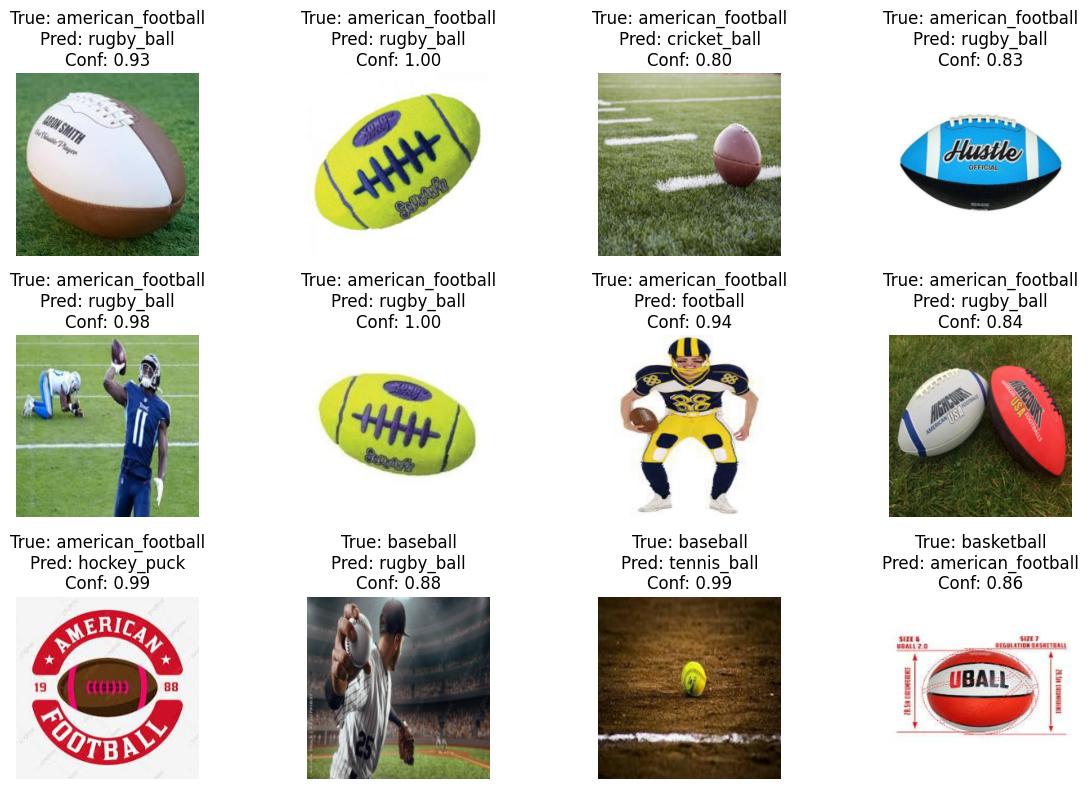

In [33]:
num_images = min(12, len(high_confidence_errors))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    item = high_confidence_errors[i]

    index = item["index"]

    image = all_images[index]

    image = image * std + mean
    image = image.clamp(0, 1)

    true_label = class_names[item["true"]]
    predicted_label = class_names[item["predicted"]]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image.permute(1, 2, 0))

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {item['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Calculate accuracy for each class

In [34]:
from sklearn.metrics import accuracy_score

for i, class_name in enumerate(class_names):

    mask = all_labels == i

    class_accuracy = accuracy_score(
        all_labels[mask],
        all_predictions[mask]
    )

    print(
        f"{class_name}: "
        f"{class_accuracy * 100:.2f}%"
    )

american_football: 77.89%
baseball: 93.33%
basketball: 88.37%
billiard_ball: 90.57%
bowling_ball: 81.65%
cricket_ball: 93.66%
football: 84.77%
golf_ball: 82.22%
hockey_ball: 86.51%
hockey_puck: 86.60%
rugby_ball: 88.71%
shuttlecock: 89.81%
table_tennis_ball: 84.21%
tennis_ball: 89.26%
volleyball: 87.16%


**Analyze:**
 
The relatively **tight accuracy range (77.9%–93.7%)** strongly suggests **weight balancing** successfully prevented majority classes from dominating the learning process.
However, the remaining **variance** is likely driven by inherent visual ambiguity between similar object shapes rather than class frequency imbalance.

# Task 2 — New test set from the internet (generalisation check)


The team lead worries the model may just memorise the original dataset. So we built a
**brand-new test set**: 30-50 photos collected from Wikimedia Commons
(`new_test_set/`), spanning several ball classes, with different cameras, angles,
lighting and backgrounds. These images are **not** in the original dataset and were
**not** used in training. We evaluate the already-trained ResNet18 on them — no
retraining — to see how the model generalises to the real world.